## 4. 株価の方向性

In [21]:
import os
import sys
from dotenv import load_dotenv
from pathlib import Path
import datetime as dt

import pandas as pd
import pandas_datareader.data as pdr
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
import mplfinance as mpf
import talib as ta

In [22]:
sys.path.append("/home/jovyan/notebook")
from Modules.get_market_data import GetMarketData
get_market_data = GetMarketData(Path('/home/jovyan/data'))

### 4.2.2 TA-Libを利用して移動平均線を描画する

[*********************100%***********************]  1 of 1 completed


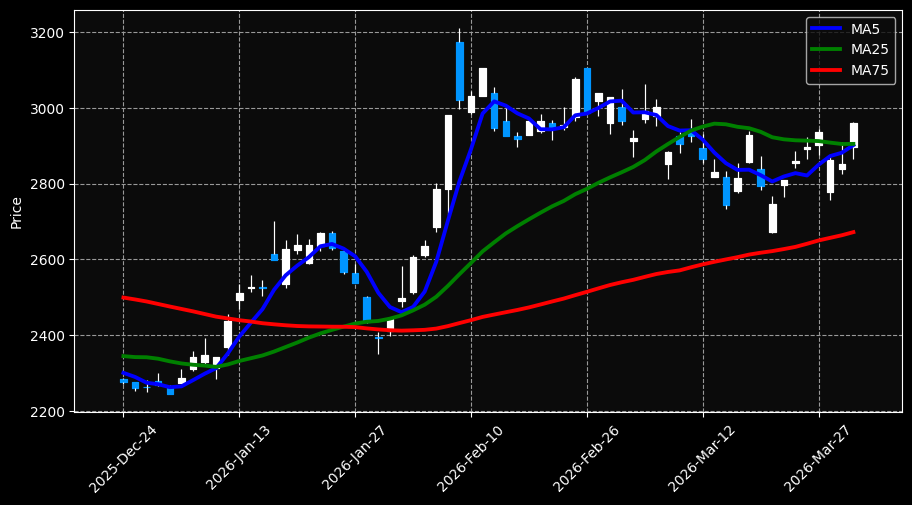

In [23]:
# データ取得終了日(現在の日付を取得)
end_date = dt.datetime.now()
# データ取得開始日(300日前の日付を計算)
start_date = end_date - dt.timedelta(days=300)
# チャート表示開始日(100日前の日付を計算)
display_start_date = end_date - dt.timedelta(days=100)

### 三越伊勢丹HD (3099.T)
df = get_market_data.get_data_from_yfinance("3099.T", start=start_date.strftime('%Y-%m-%d'), end=end_date.strftime('%Y-%m-%d'))
if isinstance(df.columns, pd.MultiIndex):
    df = df.droplevel(level=1, axis=1)
df["ma5"] = df["Close"].rolling(window=5).mean()
df["ma25"] = df["Close"].rolling(window=25).mean()
df["ma75"] = df["Close"].rolling(window=75).mean()

cdf = df[display_start_date:end_date]
apd = [mpf.make_addplot(cdf["ma5"], color='blue'),
       mpf.make_addplot(cdf["ma25"], color='green'),
       mpf.make_addplot(cdf["ma75"], color='red')]

fig, axes = mpf.plot(
    cdf, type='candle', figratio=(2, 1), addplot=apd,
    style='nightclouds', returnfig=True
)

l1, l2, l3 = axes[0].lines
axes[0].legend([l1, l2, l3], ['MA5', 'MA25', 'MA75'])
fig.show()

[*********************100%***********************]  1 of 1 completed


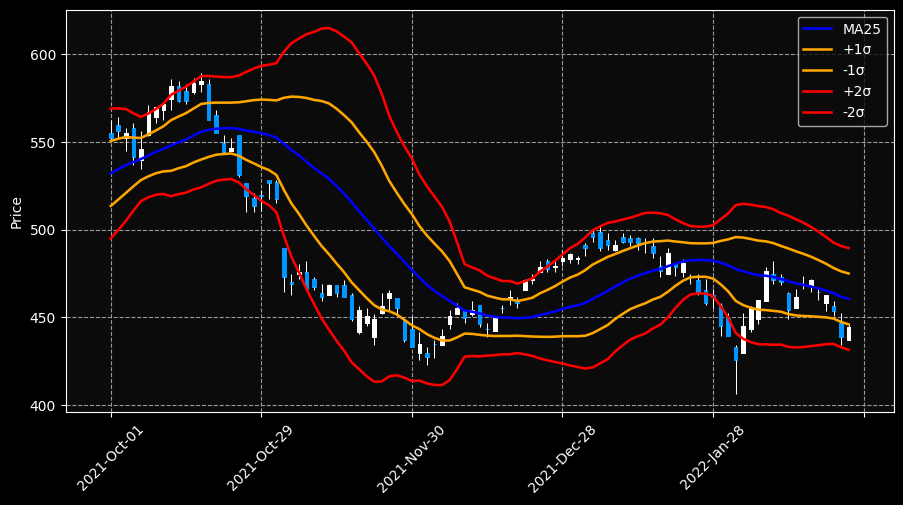

In [24]:
# データ取得終了日(2022/02/28)
end_date = dt.datetime(2022, 2, 28)
# データ取得開始日(300日前の日付を計算)
start_date = dt.datetime(2021, 1, 1)
# チャート表示開始日(100日前の日付を計算)
display_start_date = dt.datetime(2021, 10, 1)

### コニカミノルタ (4902.T)
df = get_market_data.get_data_from_yfinance("4902.T", start=start_date.strftime('%Y-%m-%d'), end=end_date.strftime('%Y-%m-%d'))
if isinstance(df.columns, pd.MultiIndex):
    df = df.droplevel(level=1, axis=1)
close = df["Close"]

# 25日移動平均線
df["ma25"] = ta.SMA(close, timeperiod=25)

# ボリンジャーバンド±1σ、±2σ
df["upper1"], _, df["lower1"] = ta.BBANDS(close, timeperiod=25, nbdevup=1, nbdevdn=1, matype=ta.MA_Type.SMA)
df["upper2"], _, df["lower2"] = ta.BBANDS(close, timeperiod=25, nbdevup=2, nbdevdn=2, matype=ta.MA_Type.SMA)

# 2021/10/01から2022/02/28までのチャートを作成
cdf = df[display_start_date:end_date]
apd = [mpf.make_addplot(cdf["ma25"], color='blue'),
       mpf.make_addplot(cdf["upper1"], color='orange'),
       mpf.make_addplot(cdf["lower1"], color='orange'),
       mpf.make_addplot(cdf["upper2"], color='red'),
       mpf.make_addplot(cdf["lower2"], color='red')]

# ラベルをつけてチャートを表示
fig, axes = mpf.plot(
    cdf, type='candle', figratio=(2, 1), addplot=apd,
    style='nightclouds', returnfig=True
)
l1, l2, l3, l4, l5 = axes[0].lines
axes[0].legend([l1, l2, l3, l4, l5], ['MA25', '+1σ', '-1σ', '+2σ', '-2σ'])
fig.show()


[*********************100%***********************]  1 of 1 completed


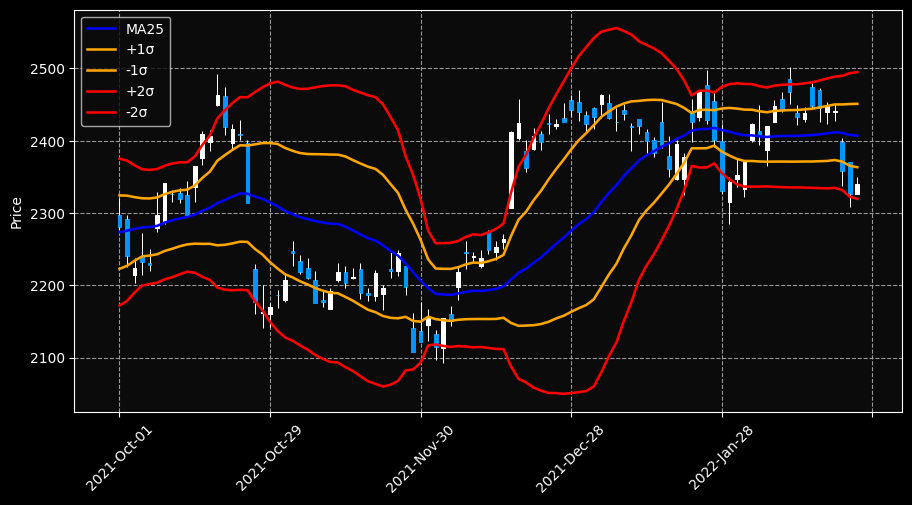

In [25]:
# データ取得終了日(2022/02/28)
end_date = dt.datetime(2022, 2, 28)
# データ取得開始日(300日前の日付を計算)
start_date = dt.datetime(2021, 1, 1)
# チャート表示開始日(100日前の日付を計算)
display_start_date = dt.datetime(2021, 10, 1)

### Canon (7751.T)
df = get_market_data.get_data_from_yfinance("7751.T", start=start_date.strftime('%Y-%m-%d'), end=end_date.strftime('%Y-%m-%d'))
if isinstance(df.columns, pd.MultiIndex):
    df = df.droplevel(level=1, axis=1)
close = df["Close"]

# 25日移動平均線
df["ma25"] = ta.SMA(close, timeperiod=25)

# ボリンジャーバンド±1σ、±2σ
df["upper1"], _, df["lower1"] = ta.BBANDS(close, timeperiod=25, nbdevup=1, nbdevdn=1, matype=ta.MA_Type.SMA)
df["upper2"], _, df["lower2"] = ta.BBANDS(close, timeperiod=25, nbdevup=2, nbdevdn=2, matype=ta.MA_Type.SMA)

# 2021/10/01から2022/02/28までのチャートを作成
cdf = df[display_start_date:end_date]
apd = [mpf.make_addplot(cdf["ma25"], color='blue'),
       mpf.make_addplot(cdf["upper1"], color='orange'),
       mpf.make_addplot(cdf["lower1"], color='orange'),
       mpf.make_addplot(cdf["upper2"], color='red'),
       mpf.make_addplot(cdf["lower2"], color='red')]

# ラベルをつけてチャートを表示
fig, axes = mpf.plot(
    cdf, type='candle', figratio=(2, 1), addplot=apd,
    style='nightclouds', returnfig=True
)
l1, l2, l3, l4, l5 = axes[0].lines
axes[0].legend([l1, l2, l3, l4, l5], ['MA25', '+1σ', '-1σ', '+2σ', '-2σ'])
fig.show()


[*********************100%***********************]  1 of 1 completed


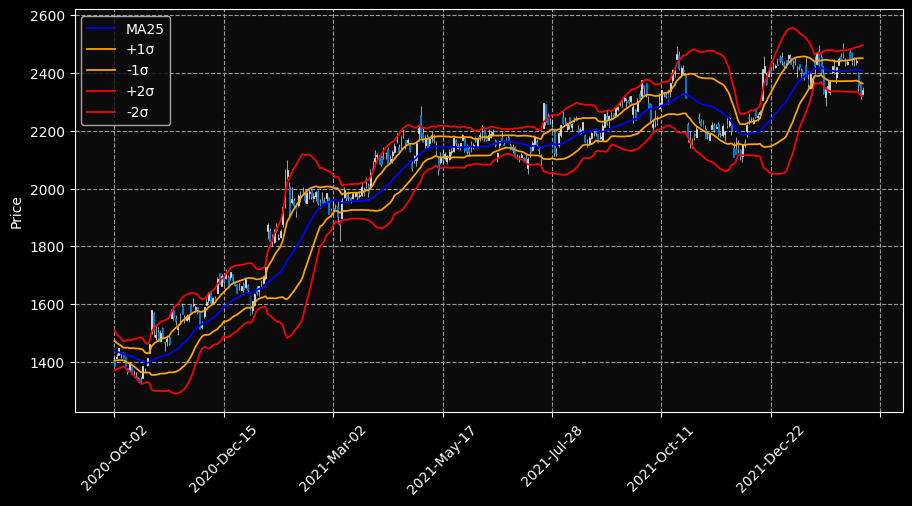

In [26]:
# データ取得終了日(2022/02/28)
end_date = dt.datetime(2022, 2, 28)
# データ取得開始日(300日前の日付を計算)
start_date = dt.datetime(2020, 1, 1)
# チャート表示開始日(100日前の日付を計算)
display_start_date = dt.datetime(2020, 10, 1)

### Canon (7751.T)
df = get_market_data.get_data_from_yfinance("7751.T", start=start_date.strftime('%Y-%m-%d'), end=end_date.strftime('%Y-%m-%d'))
if isinstance(df.columns, pd.MultiIndex):
    df = df.droplevel(level=1, axis=1)
close = df["Close"]

# 25日移動平均線
df["ma25"] = ta.SMA(close, timeperiod=25)

# ボリンジャーバンド±1σ、±2σ
df["upper1"], _, df["lower1"] = ta.BBANDS(close, timeperiod=25, nbdevup=1, nbdevdn=1, matype=ta.MA_Type.SMA)
df["upper2"], _, df["lower2"] = ta.BBANDS(close, timeperiod=25, nbdevup=2, nbdevdn=2, matype=ta.MA_Type.SMA)

# 2021/10/01から2022/02/28までのチャートを作成
cdf = df[display_start_date:end_date]
apd = [mpf.make_addplot(cdf["ma25"], color='blue'),
       mpf.make_addplot(cdf["upper1"], color='orange'),
       mpf.make_addplot(cdf["lower1"], color='orange'),
       mpf.make_addplot(cdf["upper2"], color='red'),
       mpf.make_addplot(cdf["lower2"], color='red')]

# ラベルをつけてチャートを表示
fig, axes = mpf.plot(
    cdf, type='candle', figratio=(2, 1), addplot=apd,
    style='nightclouds', returnfig=True
)
l1, l2, l3, l4, l5 = axes[0].lines
axes[0].legend([l1, l2, l3, l4, l5], ['MA25', '+1σ', '-1σ', '+2σ', '-2σ'])
fig.show()


[*********************100%***********************]  1 of 1 completed


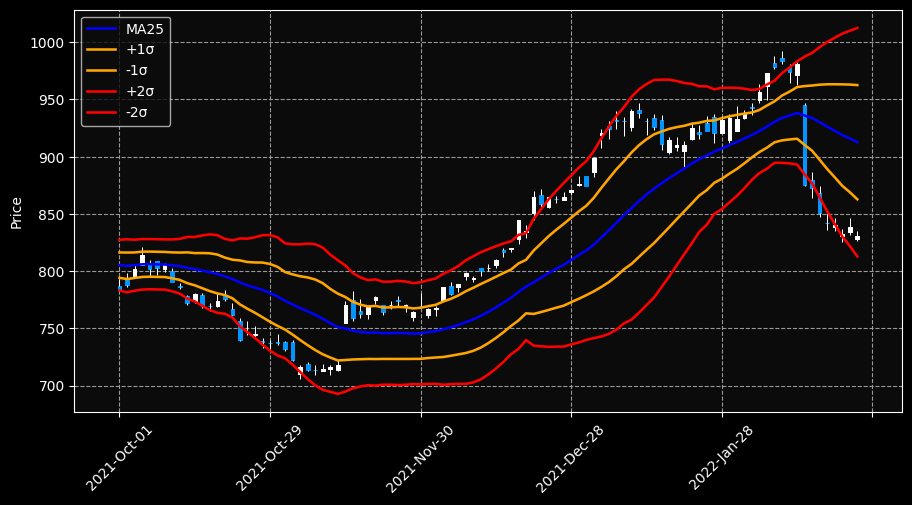

In [30]:
# データ取得終了日(2022/02/28)
end_date = dt.datetime(2022, 2, 28)
# データ取得開始日(300日前の日付を計算)
start_date = dt.datetime(2021, 1, 1)
# チャート表示開始日(100日前の日付を計算)
display_start_date = dt.datetime(2021, 10, 1)

### ゆうちょ銀行 (7182.T)
df = get_market_data.get_data_from_yfinance("7182.T", start=start_date.strftime('%Y-%m-%d'), end=end_date.strftime('%Y-%m-%d'))
if isinstance(df.columns, pd.MultiIndex):
    df = df.droplevel(level=1, axis=1)
close = df["Close"]

# 25日移動平均線
df["ma25"] = ta.SMA(close, timeperiod=25)

# ボリンジャーバンド±1σ、±2σ
df["upper1"], _, df["lower1"] = ta.BBANDS(close, timeperiod=25, nbdevup=1, nbdevdn=1, matype=ta.MA_Type.SMA)
df["upper2"], _, df["lower2"] = ta.BBANDS(close, timeperiod=25, nbdevup=2, nbdevdn=2, matype=ta.MA_Type.SMA)

# 2021/10/01から2022/02/28までのチャートを作成
cdf = df[display_start_date:end_date]
apd = [mpf.make_addplot(cdf["ma25"], color='blue'),
       mpf.make_addplot(cdf["upper1"], color='orange'),
       mpf.make_addplot(cdf["lower1"], color='orange'),
       mpf.make_addplot(cdf["upper2"], color='red'),
       mpf.make_addplot(cdf["lower2"], color='red')]

# ラベルをつけてチャートを表示
fig, axes = mpf.plot(
    cdf, type='candle', figratio=(2, 1), addplot=apd,
    style='nightclouds', returnfig=True
)
l1, l2, l3, l4, l5 = axes[0].lines
axes[0].legend([l1, l2, l3, l4, l5], ['MA25', '+1σ', '-1σ', '+2σ', '-2σ'])
fig.show()


### 平均回帰

[*********************100%***********************]  1 of 1 completed


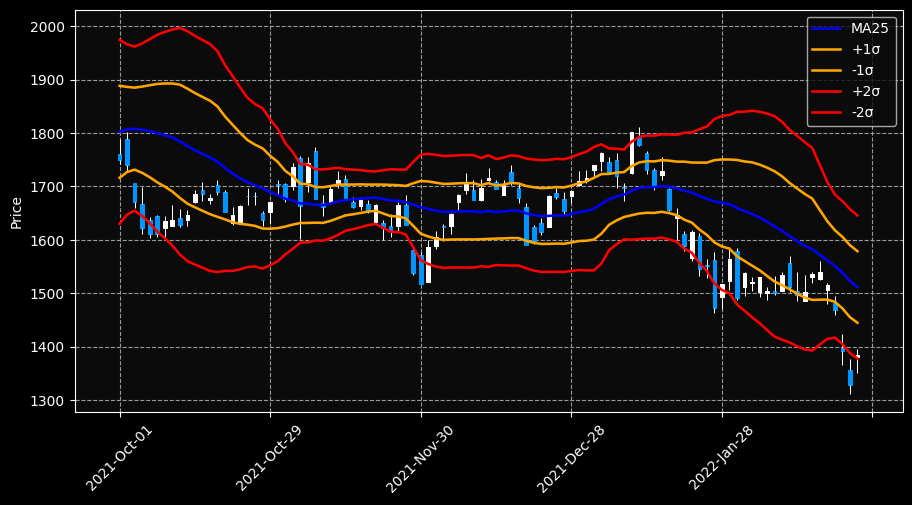

In [32]:
# データ取得終了日(2022/02/28)
end_date = dt.datetime(2022, 2, 28)
# データ取得開始日(300日前の日付を計算)
start_date = dt.datetime(2021, 1, 1)
# チャート表示開始日(100日前の日付を計算)
display_start_date = dt.datetime(2021, 10, 1)

### DMG MORI (6141.T)
df = get_market_data.get_data_from_yfinance("6141.T", start=start_date.strftime('%Y-%m-%d'), end=end_date.strftime('%Y-%m-%d'))
if isinstance(df.columns, pd.MultiIndex):
    df = df.droplevel(level=1, axis=1)
close = df["Close"]

# 25日移動平均線
df["ma25"] = ta.SMA(close, timeperiod=25)

# ボリンジャーバンド±1σ、±2σ
df["upper1"], _, df["lower1"] = ta.BBANDS(close, timeperiod=25, nbdevup=1, nbdevdn=1, matype=ta.MA_Type.SMA)
df["upper2"], _, df["lower2"] = ta.BBANDS(close, timeperiod=25, nbdevup=2, nbdevdn=2, matype=ta.MA_Type.SMA)

# 2021/10/01から2022/02/28までのチャートを作成
cdf = df[display_start_date:end_date]
apd = [mpf.make_addplot(cdf["ma25"], color='blue'),
       mpf.make_addplot(cdf["upper1"], color='orange'),
       mpf.make_addplot(cdf["lower1"], color='orange'),
       mpf.make_addplot(cdf["upper2"], color='red'),
       mpf.make_addplot(cdf["lower2"], color='red')]

# ラベルをつけてチャートを表示
fig, axes = mpf.plot(
    cdf, type='candle', figratio=(2, 1), addplot=apd,
    style='nightclouds', returnfig=True
)
l1, l2, l3, l4, l5 = axes[0].lines
axes[0].legend([l1, l2, l3, l4, l5], ['MA25', '+1σ', '-1σ', '+2σ', '-2σ'])
fig.show()


[*********************100%***********************]  1 of 1 completed


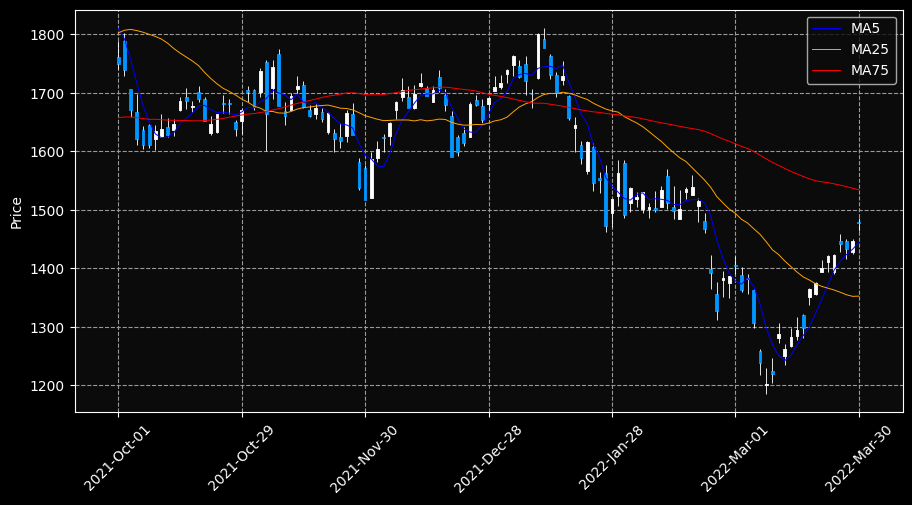

In [31]:
# データ取得終了日(2022/02/28)
end_date = dt.datetime(2022, 3, 31)
# データ取得開始日(300日前の日付を計算)
start_date = dt.datetime(2021, 1, 1)
# チャート表示開始日(100日前の日付を計算)
display_start_date = dt.datetime(2021, 10, 1)

### DMG MORI (6141.T)
df = get_market_data.get_data_from_yfinance("6141.T", start=start_date.strftime('%Y-%m-%d'), end=end_date.strftime('%Y-%m-%d'))
if isinstance(df.columns, pd.MultiIndex):
    df = df.droplevel(level=1, axis=1)
close = df["Close"]

# 移動平均線
df["ma5"] = ta.SMA(close, timeperiod=5)
df["ma25"] = ta.SMA(close, timeperiod=25)
df["ma75"] = ta.SMA(close, timeperiod=75)

# 2021/10/01から2022/03/31までのチャートを作成
cdf = df[display_start_date:end_date]
apd = [
    # 5日間移動平均線
    mpf.make_addplot(cdf["ma5"], color='blue', width=0.7),
    # 25日間移動平均線
    mpf.make_addplot(cdf["ma25"], color='orange', width=0.7),
    # 75日間移動平均線
    mpf.make_addplot(cdf["ma75"], color='red', width=0.7)
]

fig, axes = mpf.plot(
    cdf, type='candle', figratio=(2, 1), addplot=apd,
    style='nightclouds', returnfig=True
)

l1, l2, l3 = axes[0].lines
axes[0].legend([l1, l2, l3], ['MA5', 'MA25', 'MA75'])
fig.show()

[*********************100%***********************]  1 of 1 completed


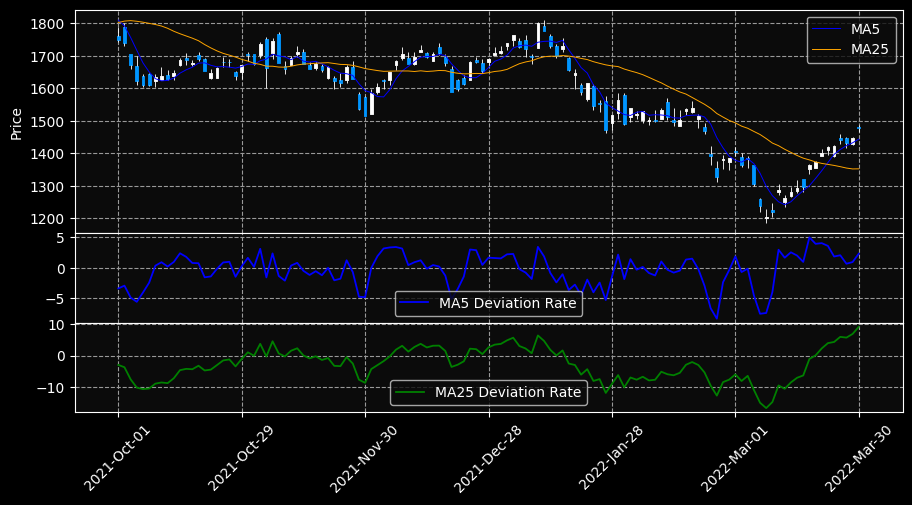

In [38]:

# データ取得終了日(2022/02/28)
end_date = dt.datetime(2022, 3, 31)
# データ取得開始日(300日前の日付を計算)
start_date = dt.datetime(2021, 1, 1)
# チャート表示開始日(100日前の日付を計算)
display_start_date = dt.datetime(2021, 10, 1)

### DMG MORI (6141.T)
df = get_market_data.get_data_from_yfinance("6141.T", start=start_date.strftime('%Y-%m-%d'), end=end_date.strftime('%Y-%m-%d'))
if isinstance(df.columns, pd.MultiIndex):
    df = df.droplevel(level=1, axis=1)
close = df["Close"]

# 移動平均線
df["ma5"] = ta.SMA(close, timeperiod=5)
df["ma25"] = ta.SMA(close, timeperiod=25)

# 乖離率
df["ma5_deviation_rate"] = (close - df["ma5"]) / df["ma5"] * 100
df["ma25_deviation_rate"] = (close - df["ma25"]) / df["ma25"] * 100

# 2021/10/01から2022/03/31までのチャートを作成
cdf = df[display_start_date:end_date]
apd = [
    # 5日間移動平均線
    mpf.make_addplot(cdf["ma5"], color='blue', width=0.7),
    # 25日間移動平均線
    mpf.make_addplot(cdf["ma25"], color='orange', width=0.7),
    # 5日間移動平均乖離率
    mpf.make_addplot(cdf["ma5_deviation_rate"], color='blue', panel=1),
    # 25日間移動平均乖離率
    mpf.make_addplot(cdf["ma25_deviation_rate"], color='green', panel=2)
]

fig, axes = mpf.plot(
    cdf, type='candle', figratio=(2, 1), addplot=apd,
    style='nightclouds', returnfig=True
)

l1, l2 = axes[0].lines
l3 = axes[2].lines[0]
l4 = axes[4].lines[0]

axes[0].legend([l1, l2], ['MA5', 'MA25'])
axes[2].legend([l3], ['MA5 Deviation Rate'])
axes[4].legend([l4], ['MA25 Deviation Rate'])

fig.show()

[*********************100%***********************]  1 of 1 completed

ValueError: not enough values to unpack (expected 6, got 5)

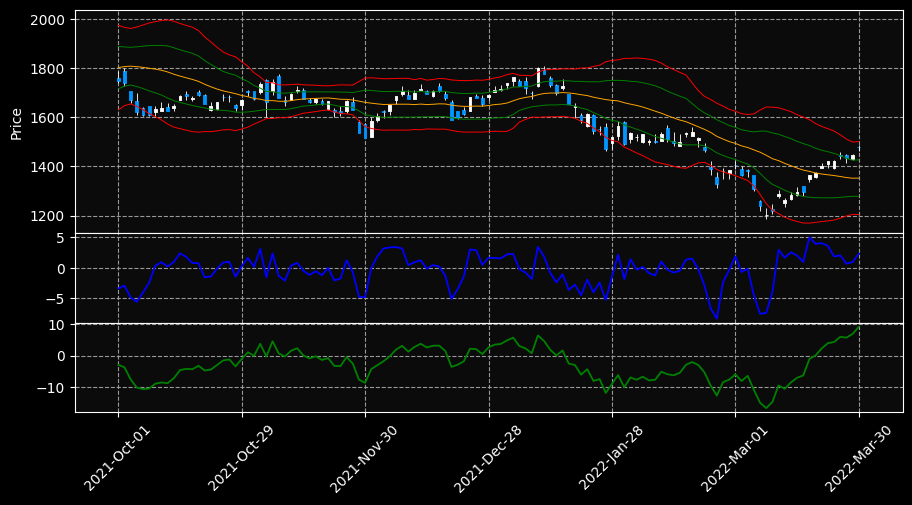

In [ ]:

# データ取得終了日(2022/02/28)
end_date = dt.datetime(2022, 3, 31)
# データ取得開始日(300日前の日付を計算)
start_date = dt.datetime(2021, 1, 1)
# チャート表示開始日(100日前の日付を計算)
display_start_date = dt.datetime(2021, 10, 1)

### DMG MORI (6141.T)
df = get_market_data.get_data_from_yfinance("6141.T", start=start_date.strftime('%Y-%m-%d'), end=end_date.strftime('%Y-%m-%d'))
if isinstance(df.columns, pd.MultiIndex):
    df = df.droplevel(level=1, axis=1)
close = df["Close"]

# 移動平均線
df["ma5"] = ta.SMA(close, timeperiod=5)
df["ma25"] = ta.SMA(close, timeperiod=25)

# 乖離率
df["MA5_deviation_rate"] = (close - df["ma5"]) / df["ma5"] * 100
df["MA25_deviation_rate"] = (close - df["ma25"]) / df["ma25"] * 100

# ボリンジャーバンド±1σ、±2σ
df["upper1"], _, df["lower1"] = ta.BBANDS(close, timeperiod=25, nbdevup=1, nbdevdn=1, matype=ta.MA_Type.SMA)
df["upper2"], _, df["lower2"] = ta.BBANDS(close, timeperiod=25, nbdevup=2, nbdevdn=2, matype=ta.MA_Type.SMA)

# 2021/10/01から2022/03/31までのチャートを作成
cdf = df[display_start_date:end_date]
apd = [
    # 5日間移動平均線
    mpf.make_addplot(cdf["ma5"], color='blue', width=0.7),
    # 25日間移動平均線
    mpf.make_addplot(cdf["ma25"], color='orange', width=0.7),
    # ボリンジャーバンド±1σ
    mpf.make_addplot(cdf["upper1"], color='green', width=0.7),
    mpf.make_addplot(cdf["lower1"], color='green', width=0.7),
    # ボリンジャーバンド±2σ
    mpf.make_addplot(cdf["upper2"], color='red', width=0.7),
    mpf.make_addplot(cdf["lower2"], color='red', width=0.7),
    # 5日間移動平均乖離率
    mpf.make_addplot(cdf["MA5_deviation_rate"], color='blue', panel=1),
    # 25日間移動平均乖離率
    mpf.make_addplot(cdf["MA25_deviation_rate"], color='green', panel=2),
]

fig, axes = mpf.plot(
    cdf, type='candle', figratio=(2, 1), addplot=apd,
    style='nightclouds', returnfig=True
)

l1, l2, l3, l4, l5, l6 = axes[0].lines
axes[0].legend([l1, l2, l3, l4, l5, l6], ['MA5', 'MA25', '+1σ', '-1σ', '+2σ', '-2σ'])
axes[2].legend(['MA5 Deviation Rate'])
axes[4].legend(['MA25 Deviation Rate'])

fig.show()
